In [1]:
import numpy as np
from PIL import Image
import requests
from transformers import AutoProcessor, AutoModel
from tensorflow.image import resize as tf_resize
import torch

2025-12-12 19:13:17.841238: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from medvqa.settings import HF_TOKEN

PROJECT_ROOT: /home/pamessina/medvqa
DOTENV_PATH: /home/pamessina/medvqa/.env


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
I0000 00:00:1765577612.494943 1353591 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43051 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:61:00.0, compute capability: 8.6


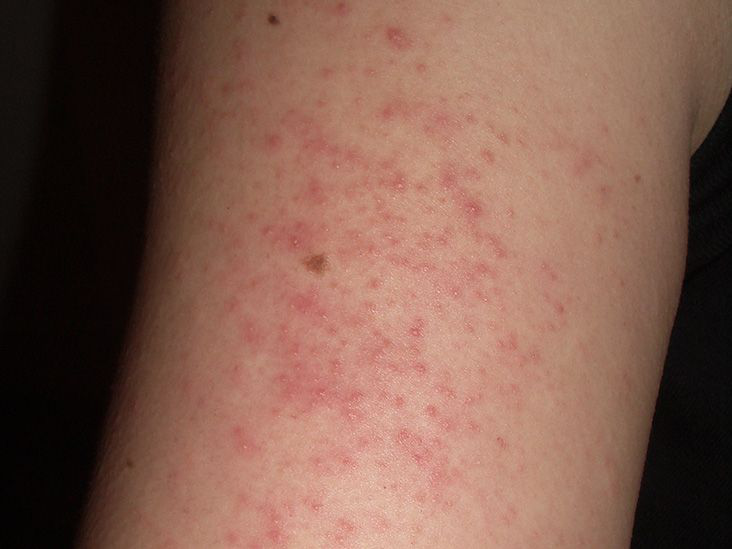

18.62% that image is 'a photo of an arm with no rash'
45.42% that image is 'a photo of an arm with a rash'
10.08% that image is 'a photo of a leg with no rash'
25.88% that image is 'a photo of a leg with a rash'


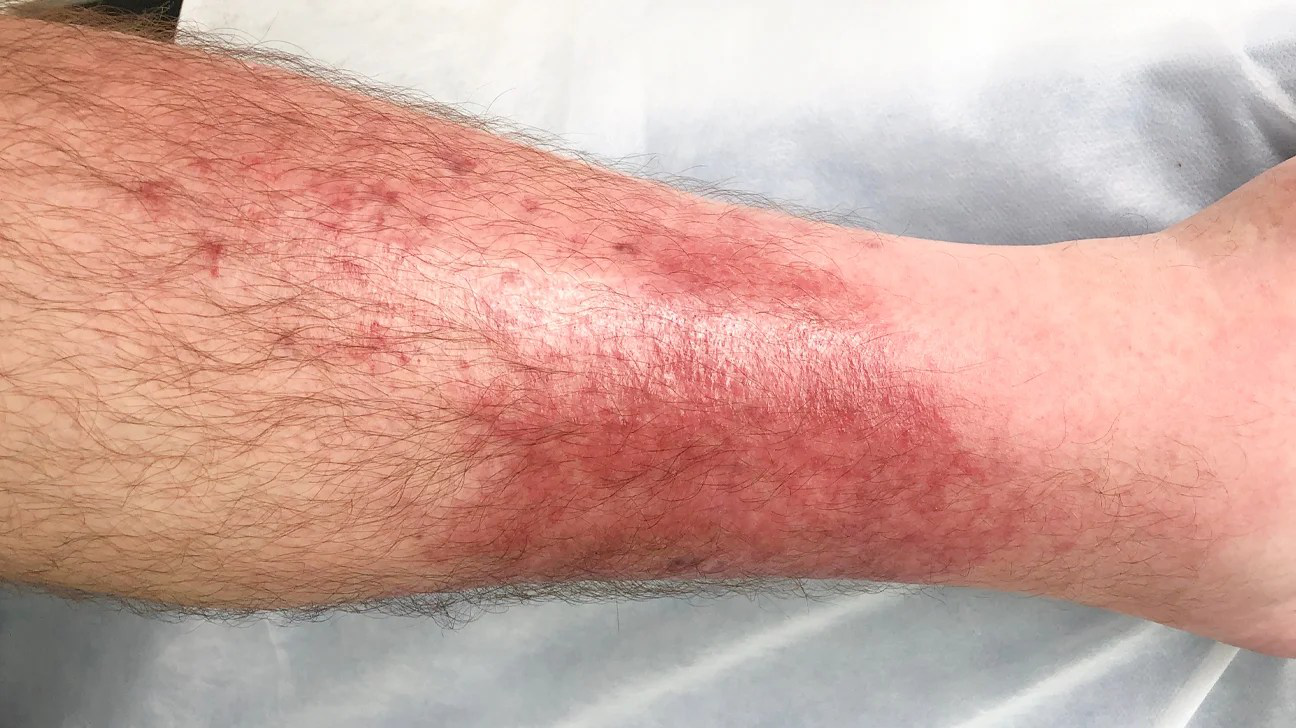

9.33% that image is 'a photo of an arm with no rash'
24.03% that image is 'a photo of an arm with a rash'
19.17% that image is 'a photo of a leg with no rash'
47.46% that image is 'a photo of a leg with a rash'
image embeddings: tensor([[-0.0106,  0.0114,  0.0346,  ..., -0.0194,  0.0062, -0.0047],
        [-0.0100,  0.0112,  0.0389,  ...,  0.0027, -0.0050,  0.0165]],
       device='cuda:0')
text embeddings: tensor([[ 0.0092,  0.0232, -0.0018,  ..., -0.0086, -0.0090,  0.0050],
        [ 0.0090,  0.0115,  0.0027,  ..., -0.0106, -0.0015,  0.0017],
        [ 0.0116,  0.0108,  0.0068,  ..., -0.0201, -0.0230,  0.0109],
        [ 0.0121, -0.0020,  0.0153,  ..., -0.0110, -0.0122,  0.0022]],
       device='cuda:0')


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModel.from_pretrained("google/medsiglip-448", token=HF_TOKEN).to(device)
processor = AutoProcessor.from_pretrained("google/medsiglip-448", token=HF_TOKEN)

# Download sample image
! wget -nc -q https://media.post.rvohealth.io/wp-content/uploads/sites/3/2020/04/Keratosis_pilaris_arm_thumb.jpg
! wget -nc -q https://i0.wp.com/post.healthline.com/wp-content/uploads/2022/03/Cellulitis-of-the-lower-legs-body7.jpg
imgs = [Image.open("Keratosis_pilaris_arm_thumb.jpg").convert("RGB"), Image.open("Cellulitis-of-the-lower-legs-body7.jpg").convert("RGB")]


# If you want to reproduce the results from MedSigLIP evals, we recommend a
# resizing operation with `tf.image.resize` to match the implementation with the
# Big Vision library (https://github.com/google-research/big_vision/blob/0127fb6b337ee2a27bf4e54dea79cff176527356/big_vision/pp/ops_image.py#L84).
# Otherwise, you can rely on the Transformers image processor's built-in
# resizing (done automatically by default and uses `PIL.Image.resize`) or use
# another resizing method.
def resize(image):
    return Image.fromarray(
        tf_resize(
            images=image, size=[448, 448], method='bilinear', antialias=False
        ).numpy().astype(np.uint8)
    )


resized_imgs = [resize(img) for img in imgs]

texts = [
    "a photo of an arm with no rash",
    "a photo of an arm with a rash",
    "a photo of a leg with no rash",
    "a photo of a leg with a rash"
]

inputs = processor(text=texts, images=resized_imgs, padding="max_length", return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

logits_per_image = outputs.logits_per_image
probs = torch.softmax(logits_per_image, dim=1)

for n_img, img in enumerate(imgs):
    display(img)  # Note this is an IPython function that will only work in a Jupyter notebook environment
    for i, label in enumerate(texts):
        print(f"{probs[n_img][i]:.2%} that image is '{label}'")

# Get the image and text embeddings
print(f"image embeddings: {outputs.image_embeds}")
print(f"text embeddings: {outputs.text_embeds}")


In [5]:
model

SiglipModel(
  (text_model): SiglipTextTransformer(
    (embeddings): SiglipTextEmbeddings(
      (token_embedding): Embedding(32000, 1152)
      (position_embedding): Embedding(64, 1152)
    )
    (encoder): SiglipEncoder(
      (layers): ModuleList(
        (0-26): 27 x SiglipEncoderLayer(
          (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
          (self_attn): SiglipAttention(
            (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
            (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
            (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
            (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
          )
          (layer_norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
          (mlp): SiglipMLP(
            (activation_fn): PytorchGELUTanh()
            (fc1): Linear(in_features=1152, out_features=4304, bias=True)
            (fc2): Linear(in_feature

In [6]:
model.vision_model

SiglipVisionTransformer(
  (embeddings): SiglipVisionEmbeddings(
    (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
    (position_embedding): Embedding(1024, 1152)
  )
  (encoder): SiglipEncoder(
    (layers): ModuleList(
      (0-26): 27 x SiglipEncoderLayer(
        (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
        (self_attn): SiglipAttention(
          (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
          (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
          (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
          (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
        )
        (layer_norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
        (mlp): SiglipMLP(
          (activation_fn): PytorchGELUTanh()
          (fc1): Linear(in_features=1152, out_features=4304, bias=True)
          (fc2): Linear(in_features=4304, out_fe

In [9]:
inputs.pixel_values.shape

torch.Size([2, 3, 448, 448])

In [7]:
import math

# 1. Reuse your existing inputs
# inputs['pixel_values'] has shape [Batch_Size, Channels, Height, Width]
# e.g., [2, 3, 448, 448]

# 2. Pass pixel values directly to the vision backbone
with torch.no_grad():
    # This skips the 'head' (Attention Pooling) and returns the transformer output
    vision_outputs = model.vision_model(pixel_values=inputs.pixel_values)

# 3. Get the sequence of patches
# Shape: [Batch_Size, Seq_Len, Hidden_Dim] -> [2, 1024, 1152]
sequence_output = vision_outputs.last_hidden_state

# 4. Reshape into a spatial volume (H, W, C)
batch_size, seq_len, hidden_dim = sequence_output.shape

# Calculate grid size (sqrt of 1024 is 32)
# We know 448 / 14 (patch size) = 32
side_dim = int(math.sqrt(seq_len)) 

# Reshape: [Batch, Height, Width, Channels]
spatial_features = sequence_output.view(batch_size, side_dim, side_dim, hidden_dim)

print(f"Original Sequence Shape: {sequence_output.shape}")
print(f"Spatial Feature Volume:  {spatial_features.shape}")

Original Sequence Shape: torch.Size([2, 1024, 1152])
Spatial Feature Volume:  torch.Size([2, 32, 32, 1152])
